<style>
:root{--navy:#102a43;--blue:#2563eb;--teal:#0f9d91;--paper:#f5f8fc;--ink:#243b53;}
.lab-hero{background:linear-gradient(130deg,#102a43,#1d4ed8);color:white;padding:28px;border-radius:18px;margin:8px 0 22px;box-shadow:0 10px 30px #102a4330}.lab-hero h1{margin:0 0 8px;font-size:2.15rem}.lab-card{background:white;border-left:5px solid var(--teal);padding:16px 20px;margin:15px 0;border-radius:10px;box-shadow:0 4px 18px #102a4318}.pill{display:inline-block;background:#dbeafe;color:#1e3a8a;padding:4px 10px;border-radius:999px;margin:2px;font-weight:600}.warn{border-left-color:#f59e0b;background:#fffbeb}.ok{border-left-color:#10b981;background:#ecfdf5}table{font-size:.92rem}h2{color:var(--navy);border-bottom:2px solid #dbeafe;padding-bottom:6px}
</style>
<div class='lab-hero'><h1>Laboratorio 4 · ML y GIS</h1><p><b>Parte 2 — Avance 75%</b> · Clasificación de cianobacterias con validación espacial</p><p>Grupo 1 · Sección 10 · Universidad del Valle de Guatemala</p></div>
<div class='lab-card'><b>Integrantes</b><br>Jorge Gabriel Palacios Sales — 231385<br>Pablo Daniel Barillas Moreno — 22193<br>Roberto Emiliano Otoniel — 23968</div>

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import HTML, Image, display
display(HTML("<style>.jp-OutputArea-output{border-radius:10px}.dataframe{border-collapse:collapse!important}.dataframe th{background:#102a43!important;color:white!important}.dataframe td,.dataframe th{padding:7px 10px!important}</style>"))
ROOT = Path.cwd()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
TABLES, FIGURES = ROOT/'outputs'/'tables', ROOT/'outputs'/'figures'
print(f'Proyecto: {ROOT.name}')

Proyecto: ml_gis_stage


## 1–3 · Datos, respuesta y predictores

<div class='lab-card ok'><b>Unidad de análisis:</b> un píxel acuático válido de 20 m en una fecha y lago. Cada fila conserva coordenadas UTM/WGS84, fecha, lago, bandas Sentinel‑2, NDVI, NDWI, CYA, respuesta binaria y bloque espacial de 1 km.</div>

Se removieron NoData, píxeles defectuosos, sombras, nubes, cirros y nieve mediante SCL; también se aplicó el contorno oficial y el criterio acuático NDWI ≥ 0. Los conteos siguientes se calcularon sobre todos los píxeles antes del muestreo uniforme de 10 000 observaciones por lago-fecha.

,fechas,pixeles_totales,observaciones_validas,cobertura_media_pct
lago,,,,
amatitlan,11,1926210,377304,19.59
atitlan,11,7725564,3041752,39.37


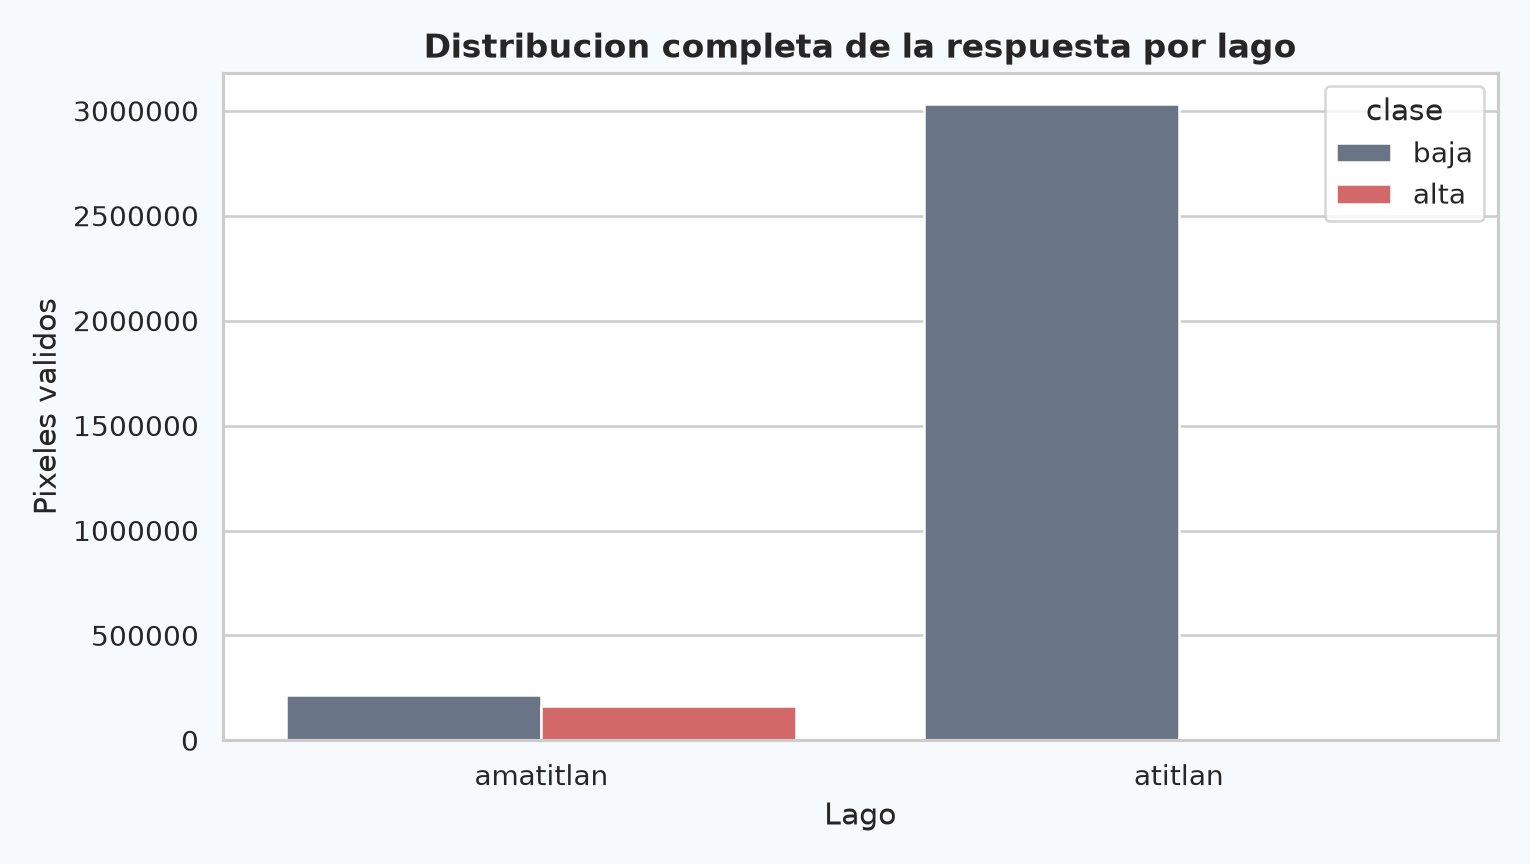

In [2]:
inventario = pd.read_csv(TABLES/'ml_inventario_limpieza.csv')
clases = pd.read_csv(TABLES/'ml_clases_por_fecha.csv')
resumen_limpieza = inventario.groupby('lago').agg(fechas=('fecha','nunique'), pixeles_totales=('pixeles_totales','sum'), observaciones_validas=('observaciones_validas','sum'), cobertura_media_pct=('cobertura_valida_pct','mean')).round(2)
display(resumen_limpieza)
display(Image(filename=str(FIGURES/'ml_distribucion_clases.png'), width=760))

### Umbral y prevención de fuga

La clase **alta** se define como CYA ≥ 100 en unidades de $10^3$ células/mL, equivalente a 100 000 células/mL. Se adopta como umbral de cribado inspirado en la alerta moderada histórica de la OMS para agua recreativa, pero el proxy Se2WaQ **no sustituye** conteos microscópicos ni mediciones de toxinas.

<div class='lab-card warn'><b>Fuga excluida:</b> CYA define la etiqueta. B02, B03 y B04 construyen CYA; NDWI comparte B03 y NDVI comparte B04. Ninguna de estas seis variables entra al entrenamiento. Se usan B05, B06, B07, B08, B8A, B11 y B12, posición normalizada y ciclo anual.</div>

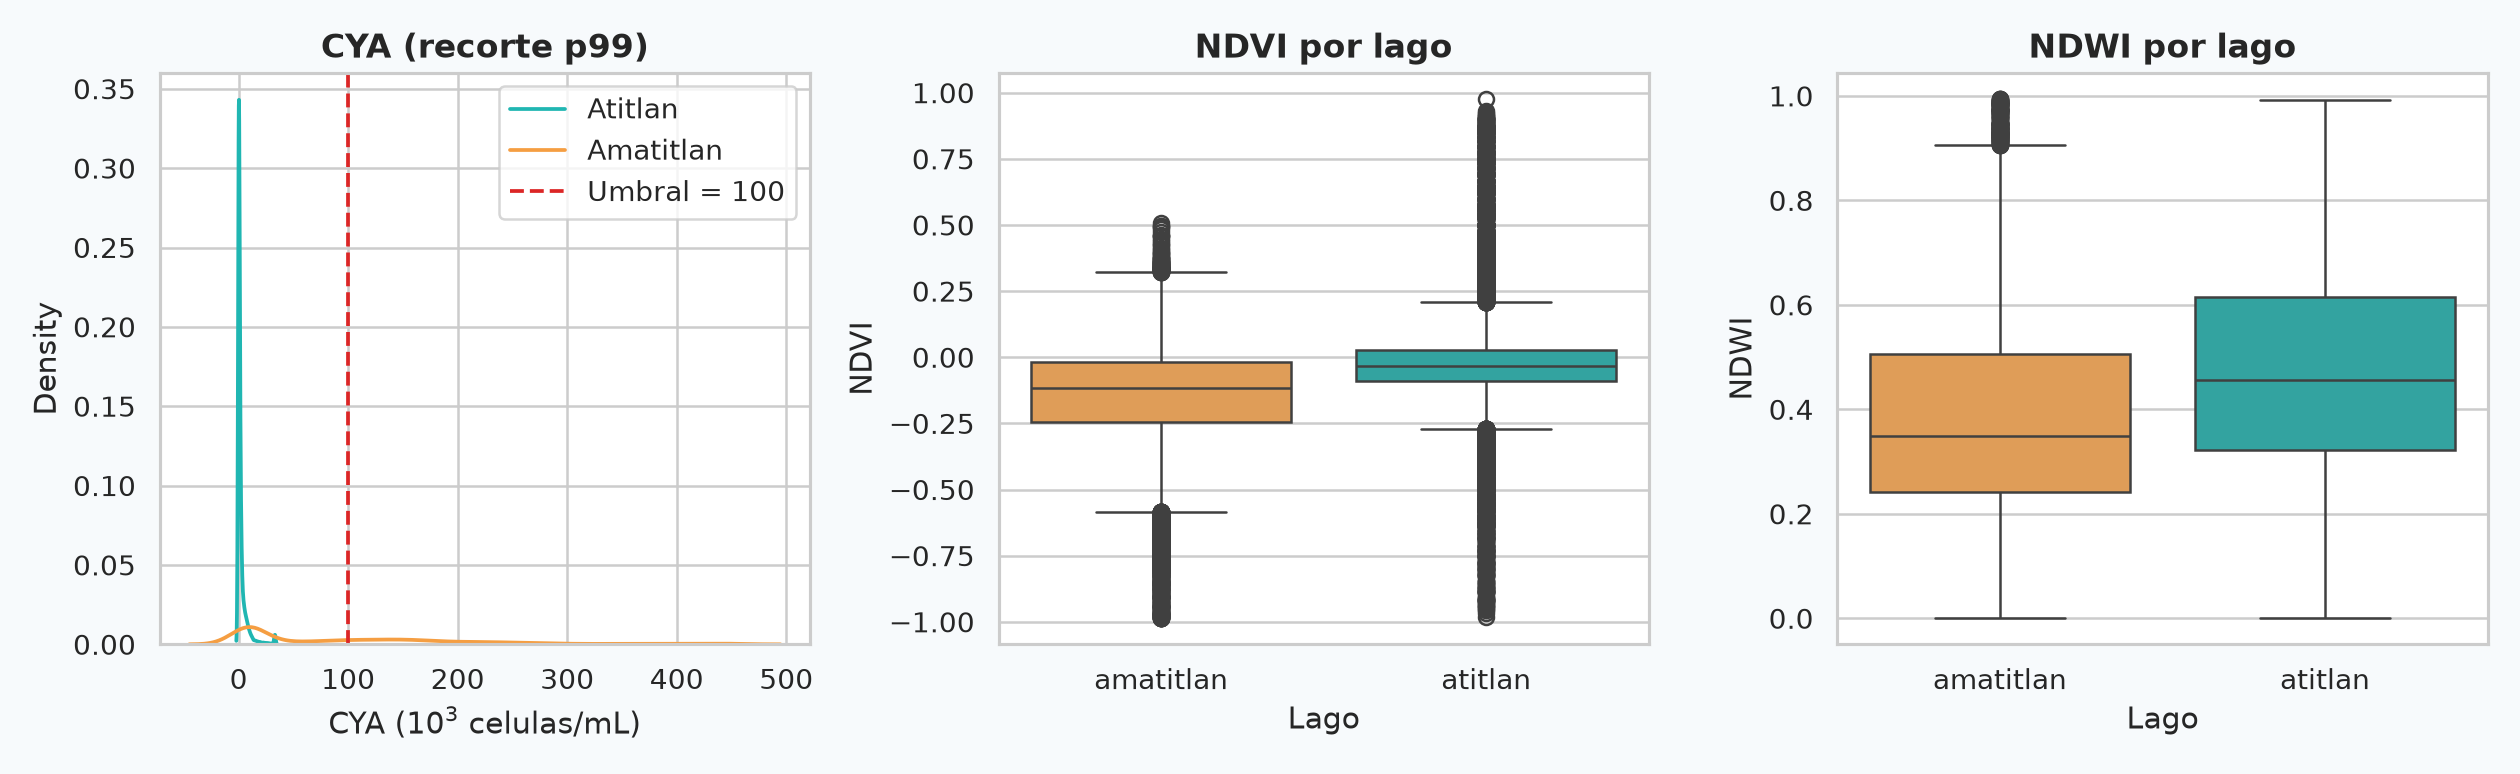

,lago,fecha,longitud,latitud,B05,B08,B11,NDVI,NDWI,CYA,cya_alta,bloque_1km
0,atitlan,2025-01-18,-91.160013,14.683710,-0.0005,0.0021,0.0004,0.555556,0.607477,0.001323,0,atitlan_698_1624
1,atitlan,2025-01-18,-91.237996,14.660998,0.0015,0.0028,0.0052,-0.253333,0.688889,0.510532,0,atitlan_689_1621
2,atitlan,2025-01-18,-91.217094,14.697169,0.0002,0.0006,0.0002,0.500000,0.842105,0.000061,0,atitlan_691_1625
3,atitlan,2025-01-18,-91.254088,14.692028,0.0004,0.0012,-0.0001,0.000000,0.801653,0.004885,0,atitlan_687_1624
4,atitlan,2025-01-18,-91.233794,14.675607,-0.0006,0.0008,0.0001,0.142857,0.860870,0.001402,0,atitlan_690_1623
5,atitlan,2025-01-18,-91.175253,14.726668,-0.0010,0.0014,-0.0003,0.866667,0.740741,0.000016,0,atitlan_696_1628
6,atitlan,2025-01-18,-91.240408,14.707651,0.0003,0.0014,0.0003,0.120000,0.735849,0.004142,0,atitlan_689_1626
7,atitlan,2025-01-18,-91.199582,14.726677,-0.0007,0.0014,0.0003,0.272727,0.722772,0.002077,0,atitlan_693_1628


In [3]:
display(Image(filename=str(FIGURES/'ml_eda_indices_cya.png'), width=1050))
dataset = pd.read_csv(ROOT/'data'/'processed'/'dataset_ml.csv.gz', nrows=8)
display(dataset[['lago','fecha','longitud','latitud','B05','B08','B11','NDVI','NDWI','CYA','cya_alta','bloque_1km']])

## 4–7 · Modelos y validación

Se comparan regresión logística, Random Forest y Gradient Boosting. Los hiperparámetros se seleccionan con validación estratificada de tres pliegues dentro del entrenamiento. Todos usan la misma prueba aleatoria 30%. La evaluación se repite con GroupKFold por bloques de 1 km, retención de la última fecha de cada lago y transferencia Atitlán→Amatitlán / Amatitlán→Atitlán.

,modelo,roc_auc_cv_ajuste,parametros,n_busqueda
0,Regresion logistica,0.994477,{'model__C': 10.0},50000
1,Random Forest,0.998312,"{'model__max_depth': None, 'model__min_samples...",50000
2,Gradient Boosting,0.998302,"{'model__learning_rate': 0.1, 'model__max_leaf...",50000


,modelo,validacion,accuracy,precision,recall,f1,roc_auc,folds,n_evaluaciones
0,Gradient Boosting,aleatoria_70_30,0.981,0.930,0.987,0.957,0.999,1,66000
1,Gradient Boosting,entre_lagos,0.903,0.653,0.800,0.674,0.934,2,220000
2,Gradient Boosting,espacial_groupkfold,0.979,0.927,0.981,0.953,0.998,5,220000
3,Gradient Boosting,temporal_ultima_fecha,0.850,0.816,0.561,0.665,0.908,1,20000
4,Random Forest,aleatoria_70_30,0.984,0.952,0.973,0.963,0.999,1,66000
5,Random Forest,entre_lagos,0.860,0.772,0.648,0.622,0.966,2,220000
6,Random Forest,espacial_groupkfold,0.982,0.952,0.963,0.958,0.998,5,220000
7,Random Forest,temporal_ultima_fecha,0.776,0.992,0.162,0.279,0.903,1,20000
8,Regresion logistica,aleatoria_70_30,0.967,0.874,0.989,0.928,0.995,1,66000
9,Regresion logistica,entre_lagos,0.899,0.636,0.955,0.762,0.964,2,220000


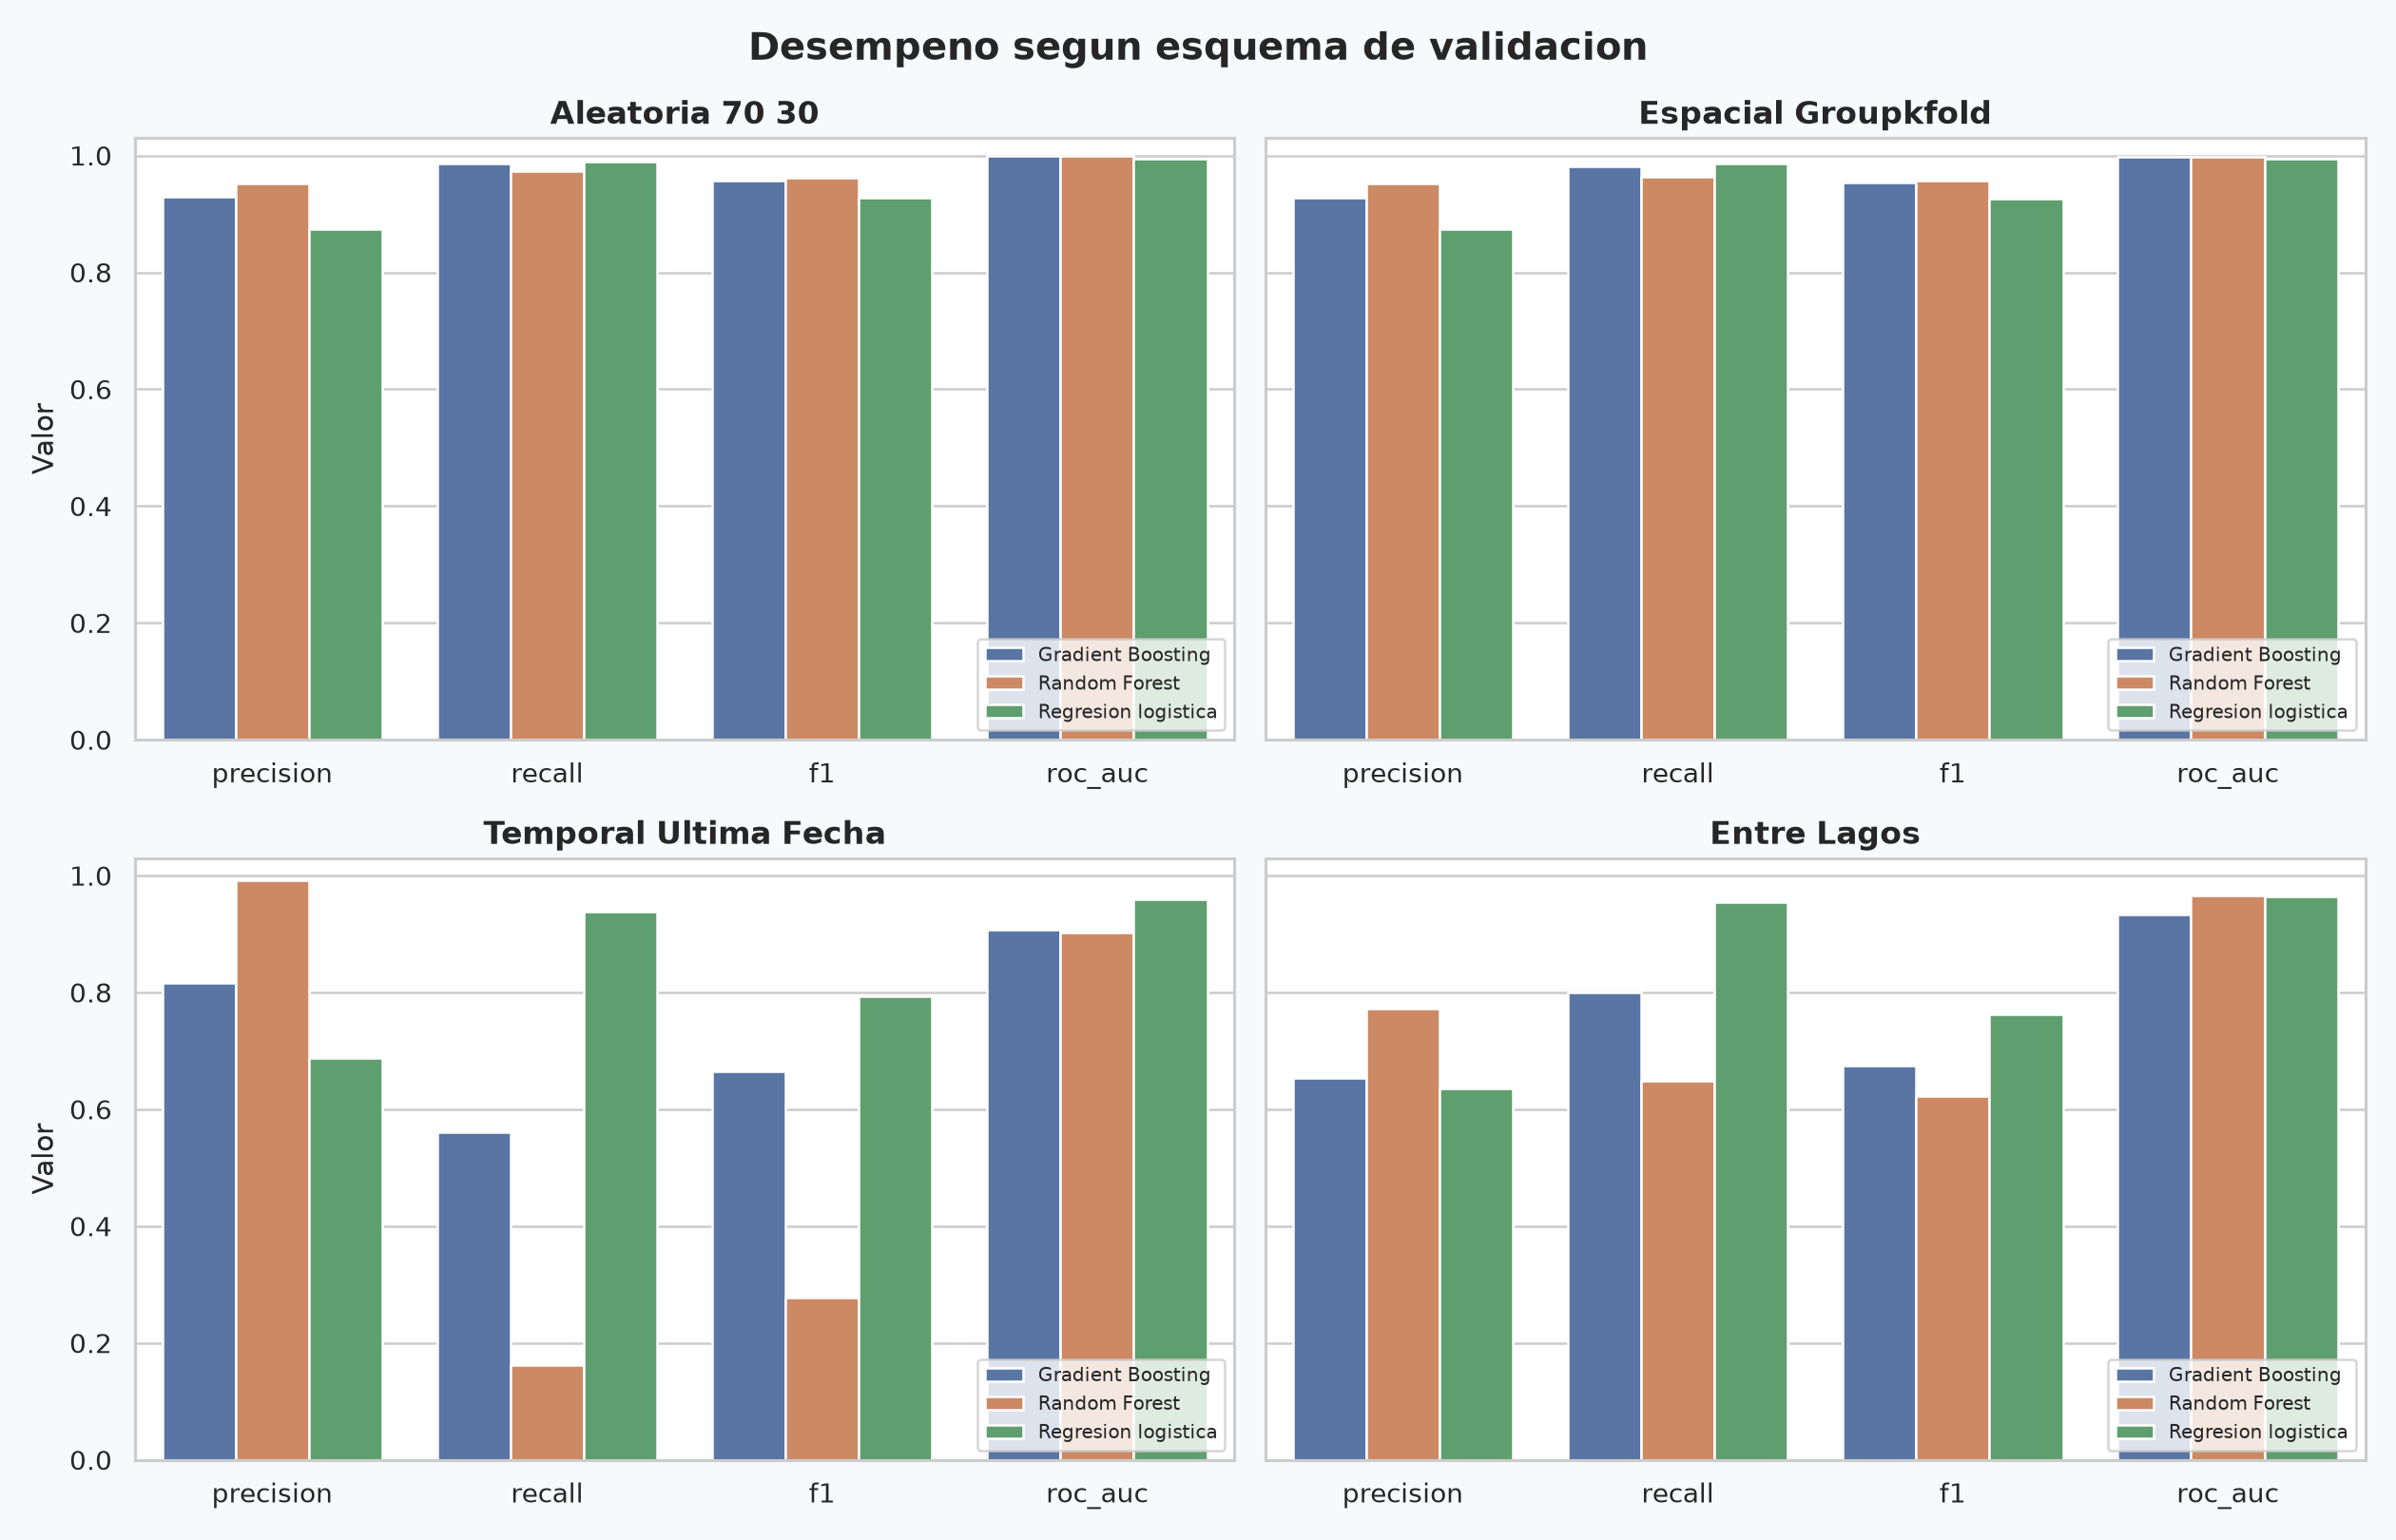

In [4]:
hiper = pd.read_csv(TABLES/'ml_hiperparametros.csv')
metricas = pd.read_csv(TABLES/'ml_metricas_resumen.csv')
display(hiper)
display(metricas.round(3))
display(Image(filename=str(FIGURES/'ml_comparacion_validaciones.png'), width=1080))

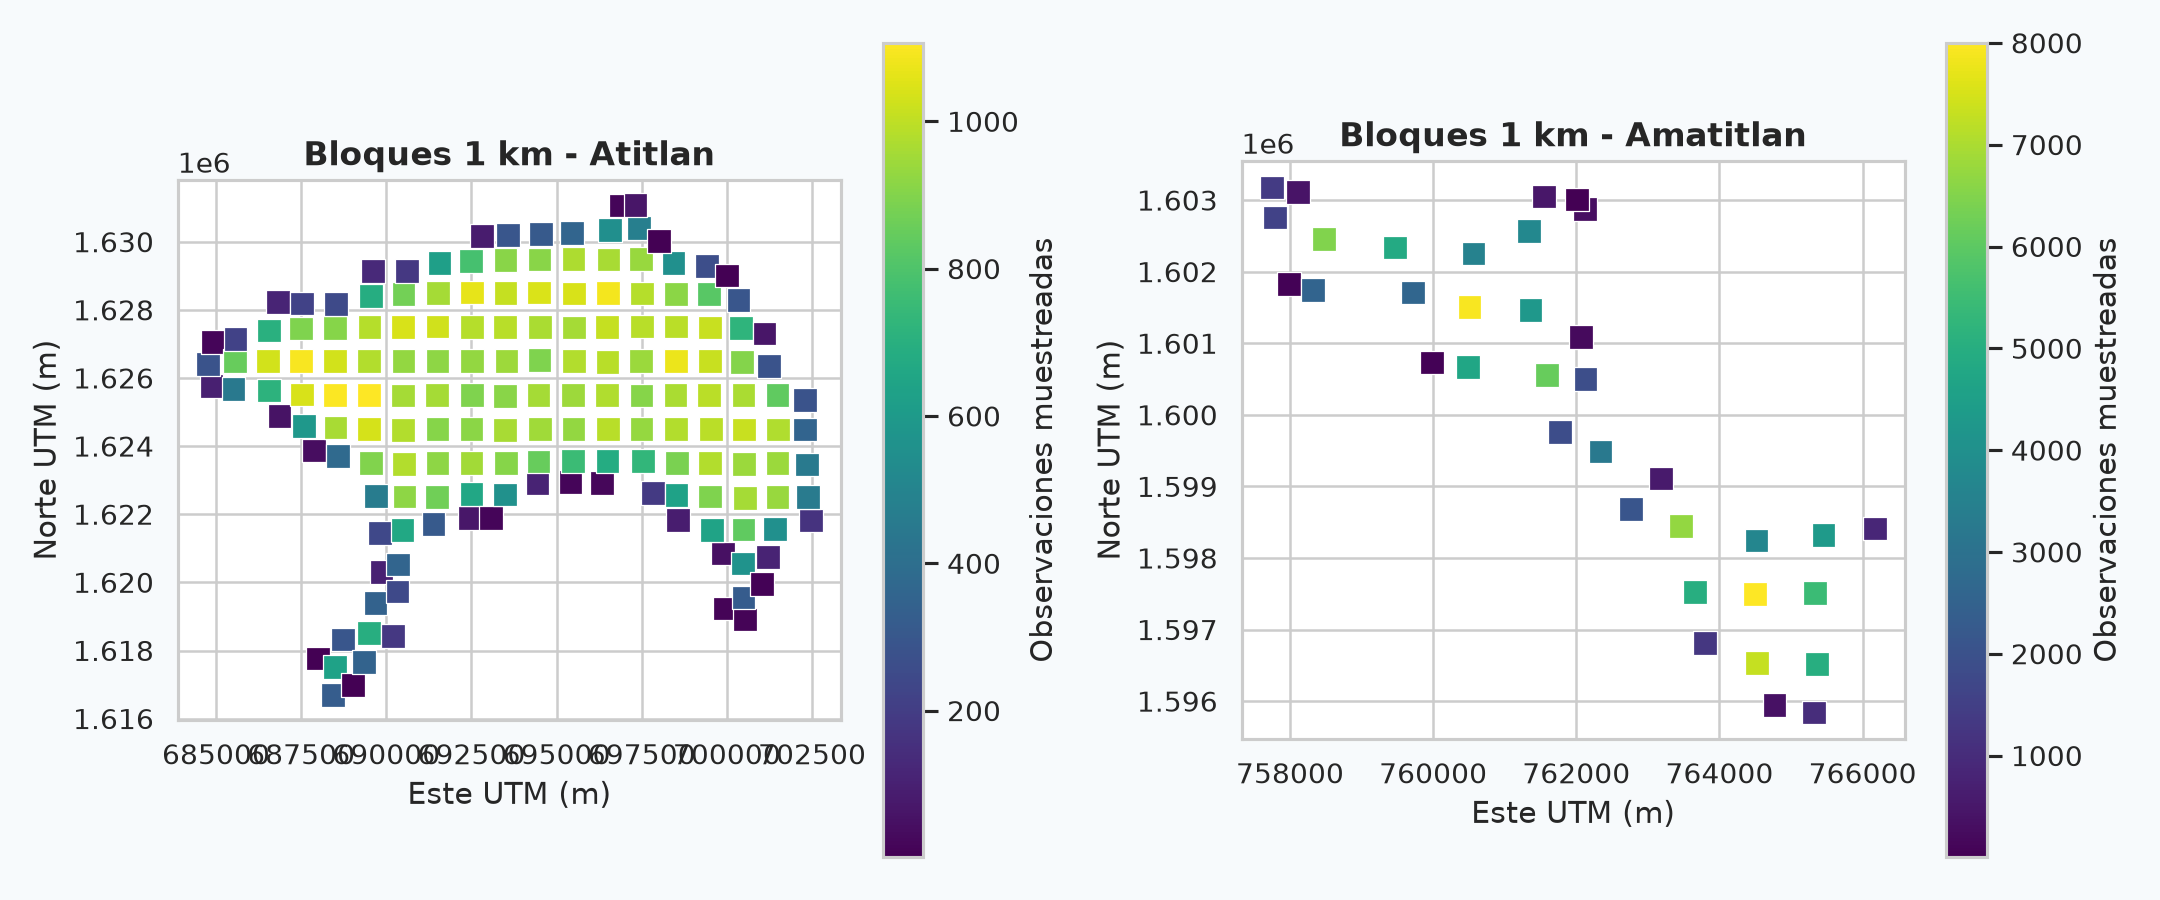

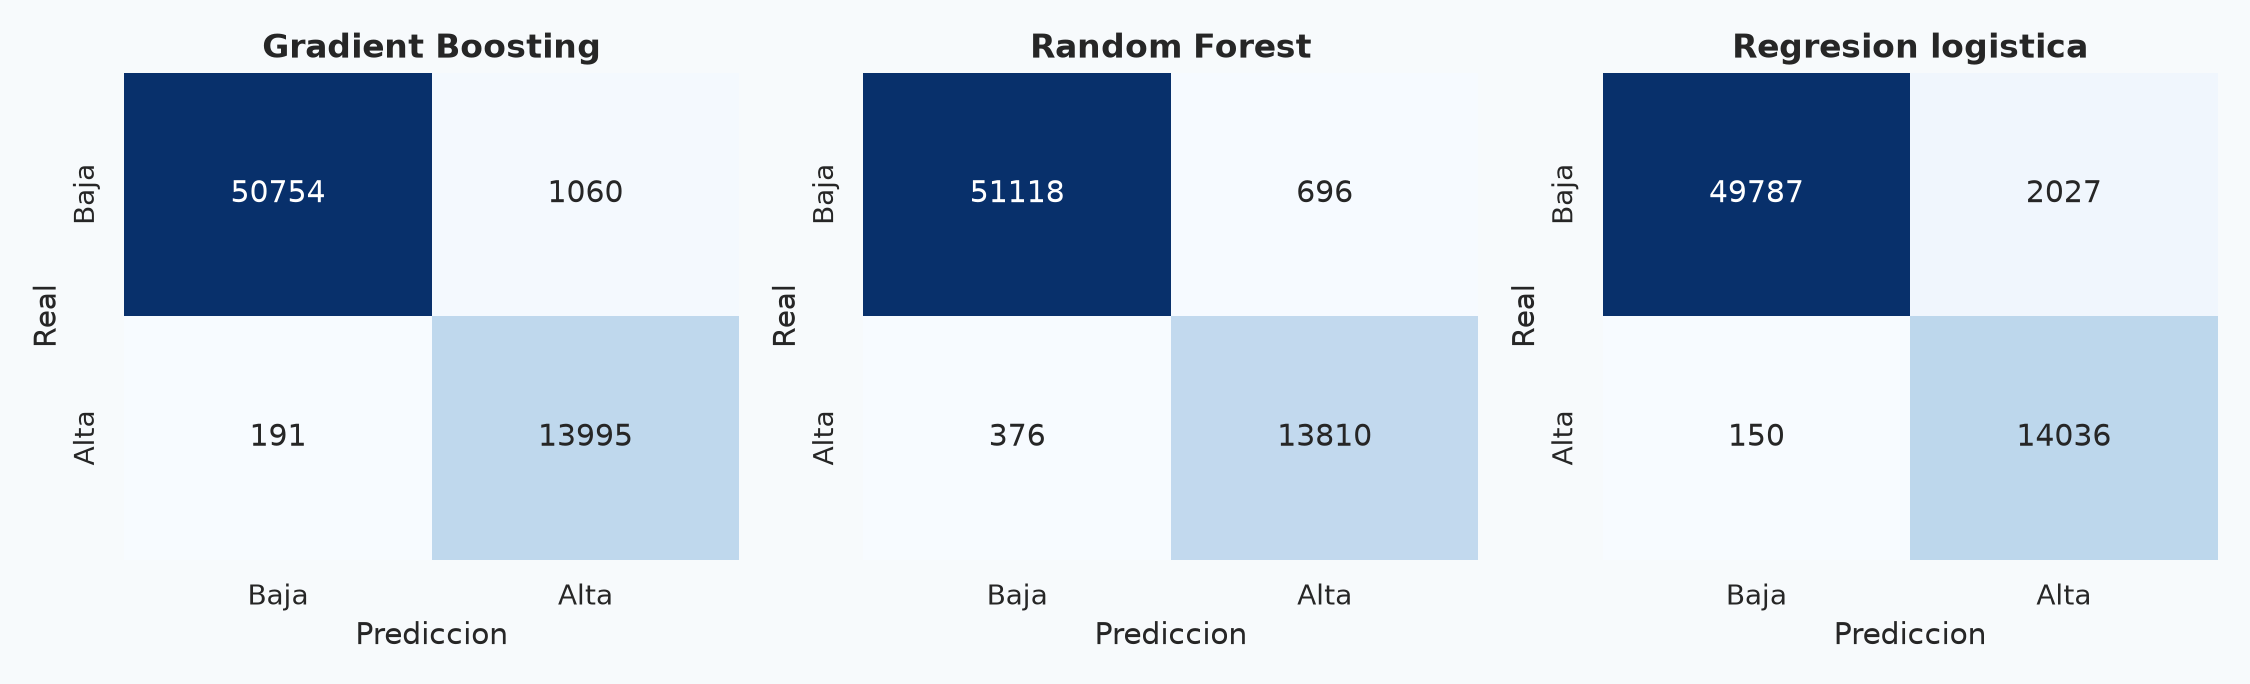

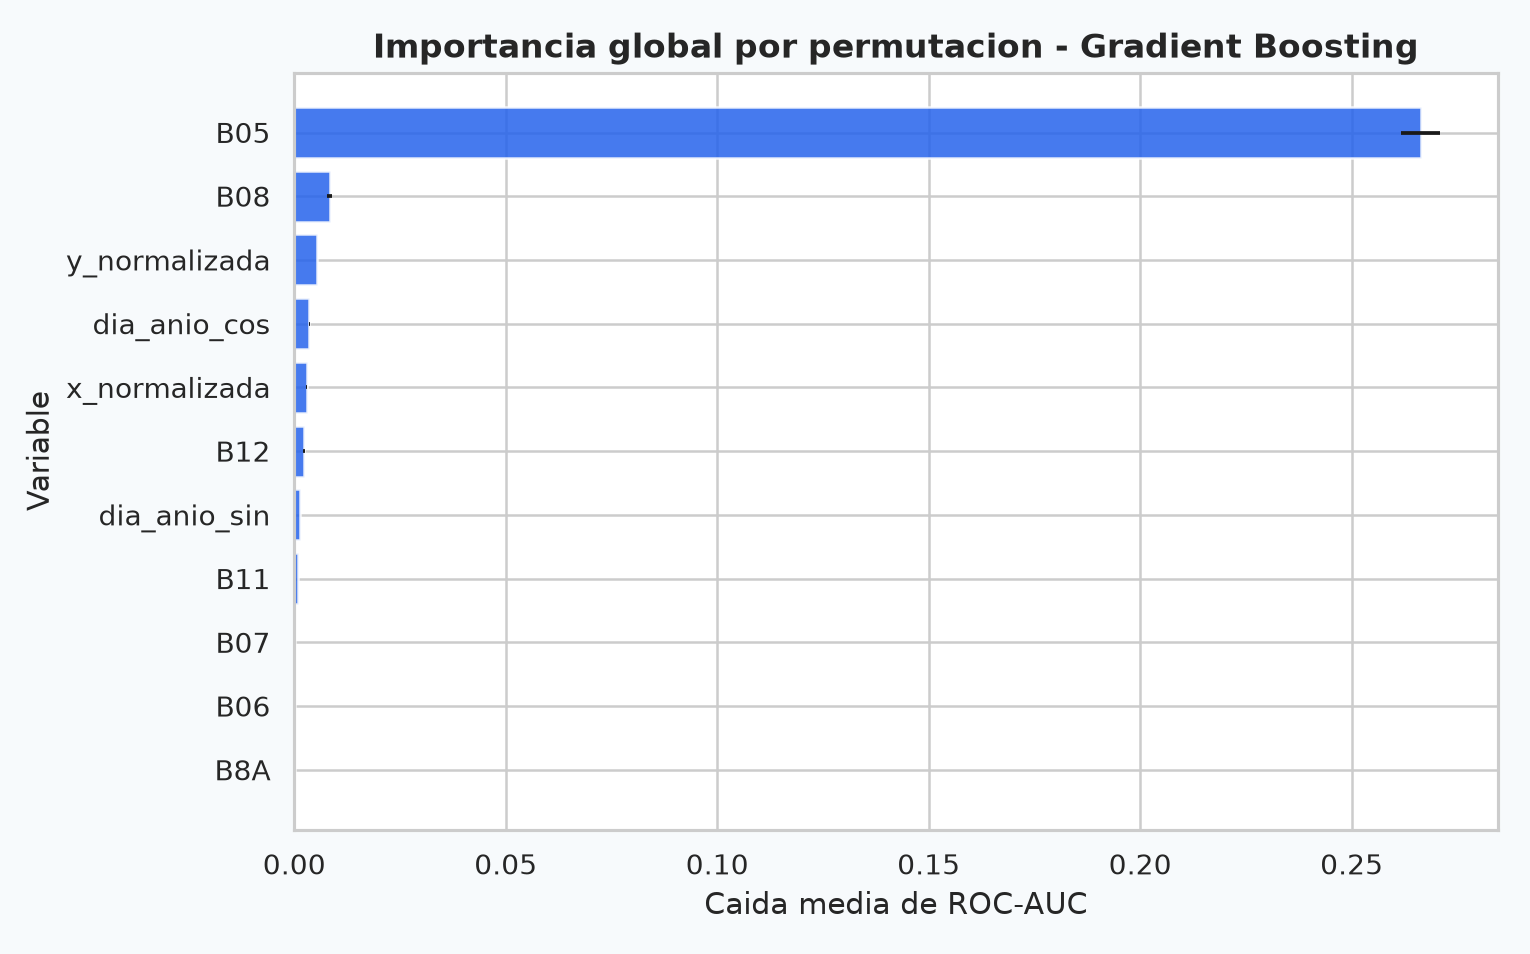

In [5]:
display(Image(filename=str(FIGURES/'ml_bloques_espaciales_1km.png'), width=1000))
display(Image(filename=str(FIGURES/'ml_matrices_confusion_aleatoria.png'), width=1000))
display(Image(filename=str(FIGURES/'ml_importancia_global.png'), width=760))

## Lectura ambiental y siguiente 25%

Los falsos negativos son el error más delicado para vigilancia: omiten zonas potencialmente problemáticas. Los falsos positivos elevan el costo de inspección, pero pueden confirmarse con muestreo in situ. Por el desbalance entre lagos se interpretan conjuntamente recall, F1 y ROC‑AUC; accuracy no se usa de manera aislada.

<div class='lab-card'><b>Reservado para la entrega final:</b> (1) SHAP global y local con dirección del efecto; (2) mapas exhaustivos de probabilidad alta y categorías de riesgo; (3) mapas FP/FN y comparación con patrones de la Parte 1; (4) conclusiones finales, limitaciones y datos adicionales.</div>